# BayesNF k-fold analysis: VI vs MAP

Aggregates the 5-fold sweep from `kfold/kfold.ipynb` into a single
comparison between variational inference (VI) and maximum a posteriori
(MAP) variants. Produces the tables and figures that support the choice
of VI for the final model.

Inputs (read from S3):

```
s3://thesis-data-ismaktam/bayesnf/runs/vi__kfold{0..4}__WY_h1_10__ffrk_full/
s3://thesis-data-ismaktam/bayesnf/runs/map__kfold{0..4}__WY_h1_10__ffrk_full/
s3://thesis-data-ismaktam/bayesnf/kfold_oof_vi.parquet
```
`kfold_oof_map.parquet` is assembled here if absent.


## 1. Setup


In [1]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from properscoring import crps_ensemble
import boto3

ROOT = Path('../../..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

s3 = boto3.client('s3')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

VI_COLOR  = '#1f77b4'
MAP_COLOR = '#d62728'
print(f'cwd: {os.getcwd()}')


cwd: /Users/etomengoi/Desktop/precip_interpolation_thesis


## 2. Config


In [2]:
S3_BUCKET    = 'thesis-data-ismaktam'
S3_RUNS_ROOT = 'bayesnf/runs'

FOLDS    = [0, 1, 2, 3, 4]
RUN_TAG  = 'kfold'
SUFFIX   = 'WY_h1_10__ffrk_full'

LOCAL_RUNS = Path('results/bayesnf/runs')
LOCAL_RUNS.mkdir(parents=True, exist_ok=True)
LOCAL_OOF  = Path('results/bayesnf')
LOCAL_OOF.mkdir(parents=True, exist_ok=True)

QUANTILE_LABELS = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95]
Q_COLS = [f'q{l:02d}' for l in QUANTILE_LABELS]

def run_name(inference, fold):
    return f'{inference}__{RUN_TAG}{fold}__{SUFFIX}'

print(f'folds  : {FOLDS}')
print(f'pattern: <inf>__{RUN_TAG}{{i}}__{SUFFIX}')


folds  : [0, 1, 2, 3, 4]
pattern: <inf>__kfold{i}__WY_h1_10__ffrk_full


## 3. Download per-fold artifacts


In [3]:
for inf in ('vi', 'map'):
    for fold in FOLDS:
        name = run_name(inf, fold)
        out_dir = LOCAL_RUNS / name
        out_dir.mkdir(parents=True, exist_ok=True)
        for fname in ('metrics.json', 'config.json', 'losses.npy'):
            s3.download_file(S3_BUCKET, f'{S3_RUNS_ROOT}/{name}/{fname}',
                             str(out_dir / fname))

print('per-fold metrics, configs, losses downloaded.')


per-fold metrics, configs, losses downloaded.


## 4. Per-fold metrics table


In [4]:
rows = []
for inf in ('vi', 'map'):
    for fold in FOLDS:
        m = json.loads((LOCAL_RUNS / run_name(inf, fold) / 'metrics.json').read_text())
        rows.append({
            'inference': inf,
            'fold'     : fold,
            'crps'     : m['crps'],
            'crps_wet' : m.get('crps_wet', np.nan),
            'mae'      : m['mae'],
            'mae_wet'  : m.get('mae_wet', np.nan),
            'rmse'     : m['rmse'],
            'rmse_wet' : m.get('rmse_wet', np.nan),
            'bias'     : m['bias'],
            'cov90'    : m['cov90'],
            'cov80'    : m['cov80'],
            'f1'       : m.get('f1', np.nan),
            'brier'    : m.get('brier', np.nan),
            'fit_s'    : m.get('fit_time_s'),
            'predict_s': m.get('predict_time_s'),
        })
df_per_fold = pd.DataFrame(rows)
with pd.option_context('display.float_format', '{:.4f}'.format):
    print('--- VI per fold ---')
    print(df_per_fold[df_per_fold['inference'] == 'vi'].drop(columns='inference').set_index('fold').to_string())
    print('\n--- MAP per fold ---')
    print(df_per_fold[df_per_fold['inference'] == 'map'].drop(columns='inference').set_index('fold').to_string())


--- VI per fold ---
       crps  crps_wet    mae  mae_wet   rmse  rmse_wet    bias  cov90  cov80     f1  brier     fit_s  predict_s
fold                                                                                                           
0    0.2853    0.7030 0.3437   0.8033 2.2218    2.2178 -0.0068 0.9547 0.9292 0.9441 0.0422 1197.8819   936.8563
1    0.2887    0.6989 0.3594   0.8083 2.8554    2.8001  0.0305 0.9557 0.9294 0.9435 0.0429 1197.4668   879.2603
2    0.2800    0.6842 0.3341   0.7726 2.0501    2.1412 -0.0044 0.9558 0.9310 0.9464 0.0410 1183.2414   900.1323
3    0.2746    0.6684 0.3387   0.7409 3.2339    2.5797  0.0215 0.9621 0.9385 0.9463 0.0402 1183.7292   888.8383
4    0.2674    0.6785 0.3203   0.7646 1.8111    1.9731 -0.0051 0.9588 0.9345 0.9438 0.0419 1174.2189   820.3360

--- MAP per fold ---
       crps  crps_wet    mae  mae_wet   rmse  rmse_wet   bias  cov90  cov80     f1  brier    fit_s  predict_s
fold                                                            

## 5. Aggregated comparison (mean +/- std across folds)


In [5]:
METRIC_COLS = ['crps', 'crps_wet', 'mae', 'mae_wet', 'rmse', 'rmse_wet',
               'bias', 'cov90', 'cov80', 'f1', 'brier']

agg = df_per_fold.groupby('inference')[METRIC_COLS].agg(['mean', 'std'])
print(agg.round(4).to_string())

summary = []
for c in METRIC_COLS:
    vi  = df_per_fold[df_per_fold['inference'] == 'vi' ][c]
    mp  = df_per_fold[df_per_fold['inference'] == 'map'][c]
    summary.append({
        'metric'  : c,
        'vi_mean' : vi.mean(),  'vi_std' : vi.std(),
        'map_mean': mp.mean(),  'map_std': mp.std(),
        'delta'   : vi.mean() - mp.mean(),
    })
df_summary = pd.DataFrame(summary).set_index('metric')
print('\n=== VI - MAP delta ===')
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(df_summary[['vi_mean', 'vi_std', 'map_mean', 'map_std', 'delta']].to_string())


             crps         crps_wet             mae         mae_wet            rmse         rmse_wet            bias           cov90           cov80              f1           brier        
             mean     std     mean     std    mean     std    mean     std    mean     std     mean     std    mean     std    mean     std    mean     std    mean     std    mean     std
inference                                                                                                                                                                                  
map        0.3105  0.0203   0.7230  0.0259  0.4244  0.0533  0.8714  0.0645  4.6664  1.3645   4.4972  1.2287  0.1154  0.0540  0.9595  0.0031  0.9338  0.0039  0.9452  0.0020  0.0417  0.0015
vi         0.2792  0.0085   0.6866  0.0143  0.3392  0.0142  0.7779  0.0281  2.4345  0.5912   2.3424  0.3384  0.0071  0.0175  0.9574  0.0030  0.9325  0.0040  0.9448  0.0014  0.0416  0.0011

=== VI - MAP delta ===
          vi_mean  vi_std  map_mean 

## 6. Bar chart with error bars


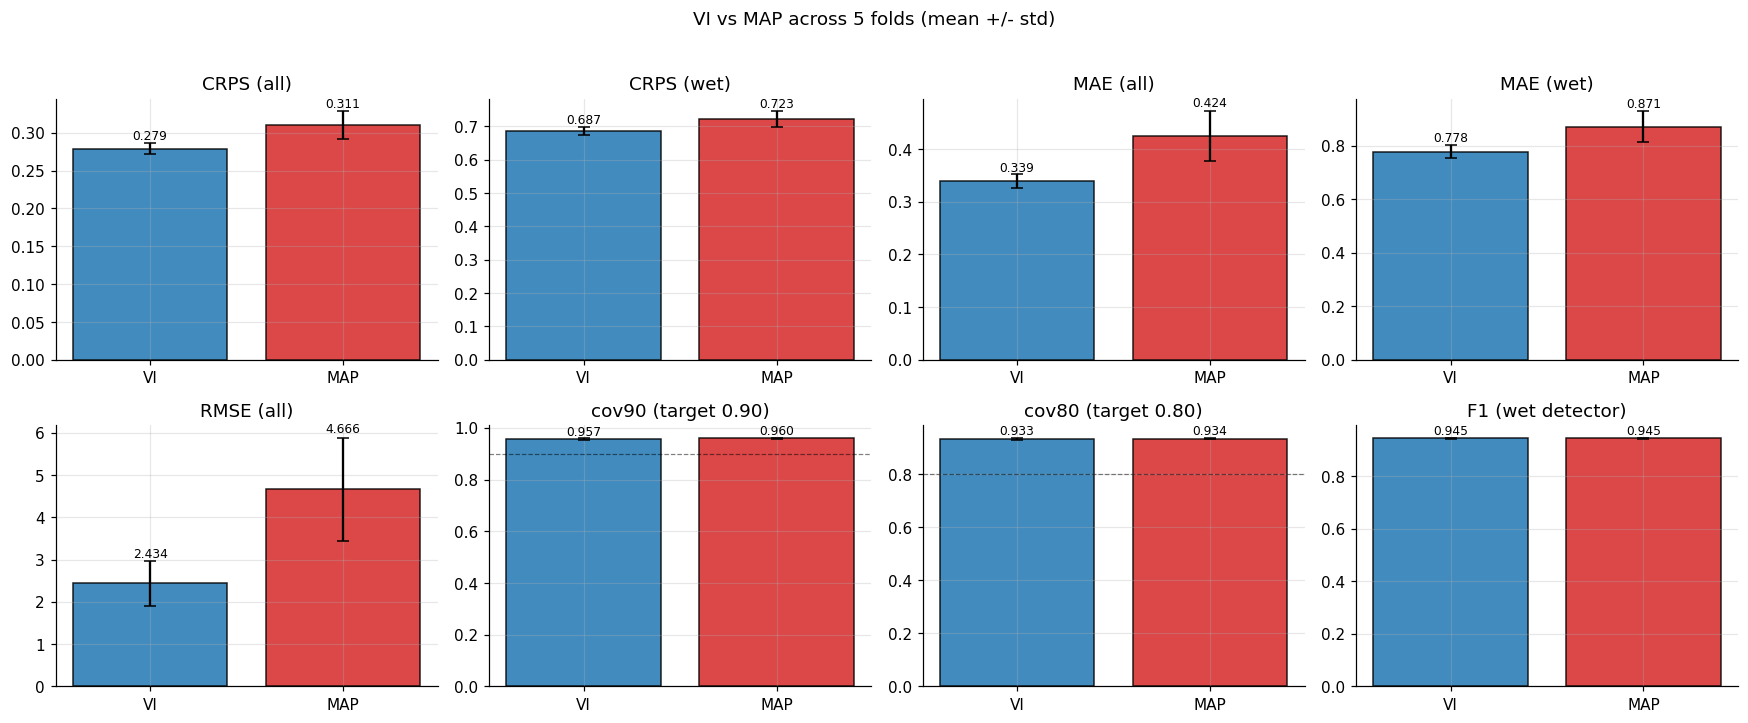

In [6]:
PLOT_METRICS = [
    ('crps',     'CRPS (all)',          'lower'),
    ('crps_wet', 'CRPS (wet)',          'lower'),
    ('mae',      'MAE (all)',           'lower'),
    ('mae_wet',  'MAE (wet)',           'lower'),
    ('rmse',     'RMSE (all)',          'lower'),
    ('cov90',    'cov90 (target 0.90)', 'target'),
    ('cov80',    'cov80 (target 0.80)', 'target'),
    ('f1',       'F1 (wet detector)',   'higher'),
]
ncols = 4
nrows = int(np.ceil(len(PLOT_METRICS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.2 * nrows))
axes = axes.flatten()

for ax, (col, label, direction) in zip(axes, PLOT_METRICS):
    vi_vals  = df_per_fold[df_per_fold['inference'] == 'vi' ][col].values
    map_vals = df_per_fold[df_per_fold['inference'] == 'map'][col].values
    means = [vi_vals.mean(), map_vals.mean()]
    stds  = [vi_vals.std(),  map_vals.std()]
    ax.bar(['VI', 'MAP'], means, yerr=stds, capsize=4,
           color=[VI_COLOR, MAP_COLOR], alpha=0.85, edgecolor='black')
    for i, (v, s) in enumerate(zip(means, stds)):
        ax.text(i, v + s * 1.05, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    if direction == 'target' and col.startswith('cov'):
        target = 0.90 if col == 'cov90' else 0.80
        ax.axhline(target, color='black', ls='--', lw=0.8, alpha=0.5)
    ax.set_title(label)

for ax in axes[len(PLOT_METRICS):]:
    ax.axis('off')

fig.suptitle('VI vs MAP across 5 folds (mean +/- std)', y=1.02)
plt.tight_layout()
plt.savefig('thesis/text/images/05/kfold_vi_vs_map_bars.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Loss curves per fold


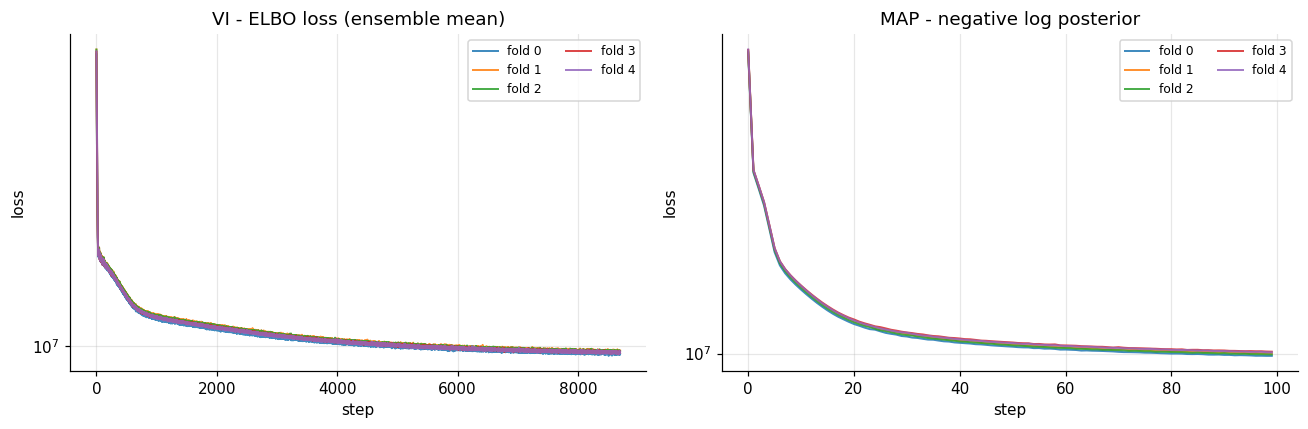

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for fold in FOLDS:
    for ax, inf, color in [(axes[0], 'vi', VI_COLOR), (axes[1], 'map', MAP_COLOR)]:
        losses = np.load(LOCAL_RUNS / run_name(inf, fold) / 'losses.npy')
        if losses.ndim > 2:
            losses = losses.reshape(-1, losses.shape[-1])
        m = losses.mean(0)
        ax.plot(m, label=f'fold {fold}', alpha=0.85, lw=1.3)

axes[0].set_title('VI - ELBO loss (ensemble mean)')
axes[1].set_title('MAP - negative log posterior')
for ax in axes:
    ax.set_xlabel('step')
    ax.set_ylabel('loss')
    ax.set_yscale('symlog')
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('thesis/text/images/05/kfold_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Assemble OOF predictions (VI + MAP)

Tries `s3://.../bayesnf/kfold_oof_{inf}.parquet` first. If that key is
missing, downloads the 5 per-fold `preds.parquet` and concatenates them,
then uploads the result back to S3 for reuse.


In [8]:
def _load_oof(inf):
    out = LOCAL_OOF / f'kfold_oof_{inf}.parquet'
    s3_key = f'bayesnf/kfold_oof_{inf}.parquet'
    try:
        s3.download_file(S3_BUCKET, s3_key, str(out))
        return pd.read_parquet(out)
    except s3.exceptions.ClientError:
        pass
    print(f'  S3 key {s3_key} missing — assembling from {len(FOLDS)} fold parquets...')
    chunks = []
    for fold in FOLDS:
        name = run_name(inf, fold)
        local = LOCAL_RUNS / name / 'preds.parquet'
        s3.download_file(S3_BUCKET, f'{S3_RUNS_ROOT}/{name}/preds.parquet', str(local))
        df = pd.read_parquet(local)
        df['fold'] = fold
        chunks.append(df)
    oof = pd.concat(chunks, ignore_index=True)
    oof.to_parquet(out, index=False)
    s3.upload_file(str(out), S3_BUCKET, s3_key)
    return oof

oof_vi  = _load_oof('vi' )
oof_map = _load_oof('map')
for df in (oof_vi, oof_map):
    df['datetime'] = pd.to_datetime(df['datetime'])

print(f'VI  OOF: {len(oof_vi ):>9,} rows / {oof_vi ["station_id"].nunique()} stations')
print(f'MAP OOF: {len(oof_map):>9,} rows / {oof_map["station_id"].nunique()} stations')


VI  OOF: 7,179,832 rows / 1966 stations
MAP OOF: 7,179,832 rows / 1966 stations


## 9. Attach station coordinates

Coordinates are streamed straight from the fold parquets in S3 with
column projection — only `station_id`, `latitude`, `longitude` are
transferred, no local files written. The union of the 5 fold-test
files covers every OOF station.


In [9]:
import pyarrow.parquet as pq
import pyarrow.fs as pafs

fs = pafs.S3FileSystem(region='eu-north-1')
coords_parts = []
for fold in FOLDS:
    path = f'{S3_BUCKET}/bayesnf/data/bayesnf_fold{fold}_test.parquet'
    tbl = pq.read_table(
        path, columns=['station_id', 'latitude', 'longitude'], filesystem=fs,
    )
    coords_parts.append(tbl.to_pandas().drop_duplicates('station_id'))

coords = (pd.concat(coords_parts, ignore_index=True)
            .drop_duplicates('station_id')
            .rename(columns={'latitude': 'lat', 'longitude': 'lon'})
            .set_index('station_id'))
print(f'coords loaded for {len(coords)} stations')

oof_vi  = oof_vi .merge(coords, left_on='station_id', right_index=True, how='left')
oof_map = oof_map.merge(coords, left_on='station_id', right_index=True, how='left')


coords loaded for 1966 stations


## 10. Per-day CRPS distribution


per-day CRPS computed in 2.6s


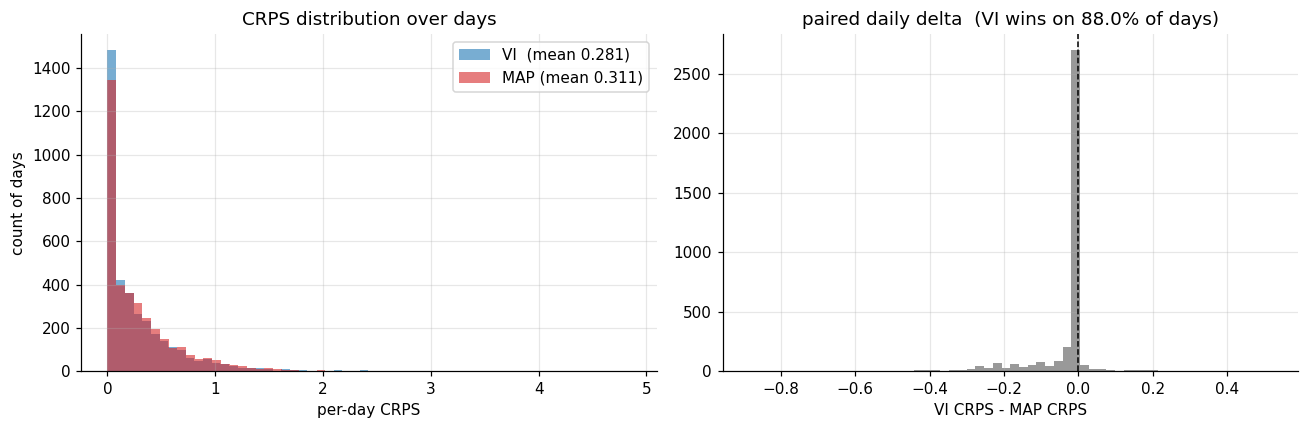

In [10]:
def _per_day_crps(df):
    y = df['observed_mm'].to_numpy()
    Q = df[Q_COLS].to_numpy()
    s = crps_ensemble(y, Q)
    return df.assign(_crps=s).groupby('datetime')['_crps'].mean()

t0 = time.time()
crps_vi  = _per_day_crps(oof_vi )
crps_map = _per_day_crps(oof_map)
print(f'per-day CRPS computed in {time.time()-t0:.1f}s')

dly = pd.DataFrame({'vi': crps_vi, 'map': crps_map}).dropna()
dly['delta'] = dly['vi'] - dly['map']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dly['vi'],  bins=60, alpha=0.6, color=VI_COLOR,  label=f'VI  (mean {dly["vi" ].mean():.3f})')
axes[0].hist(dly['map'], bins=60, alpha=0.6, color=MAP_COLOR, label=f'MAP (mean {dly["map"].mean():.3f})')
axes[0].set_xlabel('per-day CRPS')
axes[0].set_ylabel('count of days')
axes[0].legend()
axes[0].set_title('CRPS distribution over days')

axes[1].hist(dly['delta'], bins=60, color='gray', alpha=0.8)
axes[1].axvline(0, color='black', ls='--', lw=1)
axes[1].set_xlabel('VI CRPS - MAP CRPS')
axes[1].set_title(f'paired daily delta  (VI wins on {(dly["delta"] < 0).mean()*100:.1f}% of days)')
plt.tight_layout()
plt.savefig('thesis/text/images/05/kfold_per_day_crps.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Day selection

* `best_vi`  - day where VI improves on MAP the most.
* `best_map` - day where MAP improves on VI the most.
* `balanced` - representative day where the two are close (median |delta|).


In [11]:
best_vi  = dly['delta'].idxmin()
best_map = dly['delta'].idxmax()
balanced = (dly['delta'].abs() - dly['delta'].abs().median()).abs().idxmin()

print(f'best_vi  : {best_vi.date()}   delta={dly.loc[best_vi ,"delta"]:+.4f}  '
      f'vi={dly.loc[best_vi ,"vi"]:.4f} map={dly.loc[best_vi ,"map"]:.4f}')
print(f'best_map : {best_map.date()}  delta={dly.loc[best_map,"delta"]:+.4f}  '
      f'vi={dly.loc[best_map,"vi"]:.4f} map={dly.loc[best_map,"map"]:.4f}')
print(f'balanced : {balanced.date()}  delta={dly.loc[balanced,"delta"]:+.4f}  '
      f'vi={dly.loc[balanced,"vi"]:.4f} map={dly.loc[balanced,"map"]:.4f}')

DAYS = [(best_vi, 'best for VI'),
        (best_map, 'best for MAP'),
        (balanced, 'balanced')]


best_vi  : 2020-08-30   delta=-0.8859  vi=2.4788 map=3.3647
best_map : 2023-11-08  delta=+0.5193  vi=0.6816 map=0.1623
balanced : 2018-04-15  delta=-0.0038  vi=0.2505 map=0.2542


## 12. Station-scatter maps for the three days

Two rows: row 1 = mean precipitation, row 2 = predictive spread (q95 - q05).
Three columns: VI, MAP, observed.


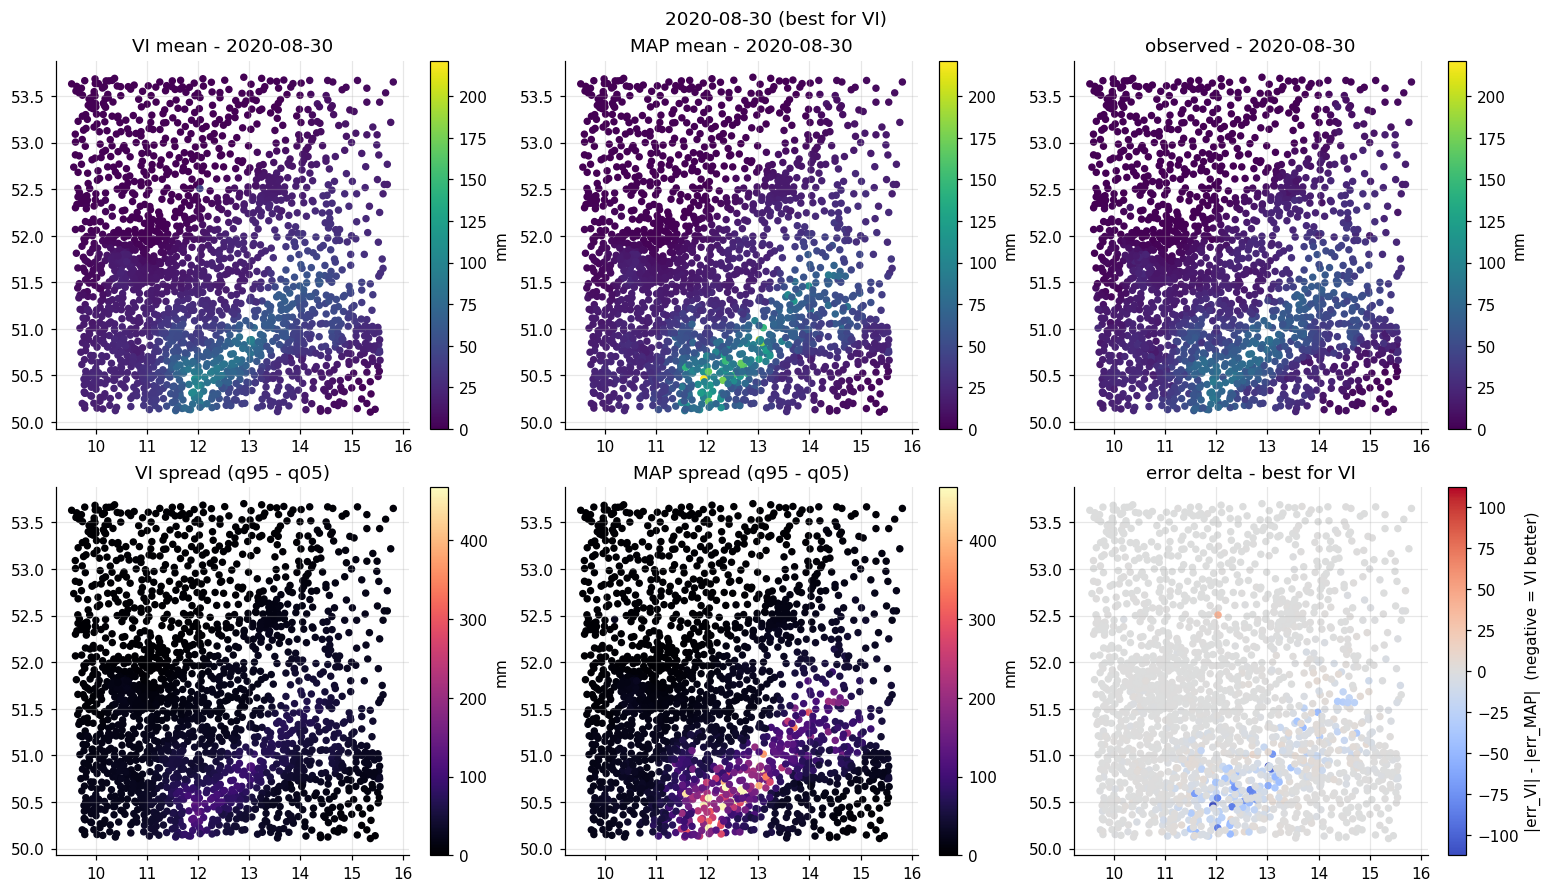

ValueError: operands could not be broadcast together with shapes (786,) (1966,) 

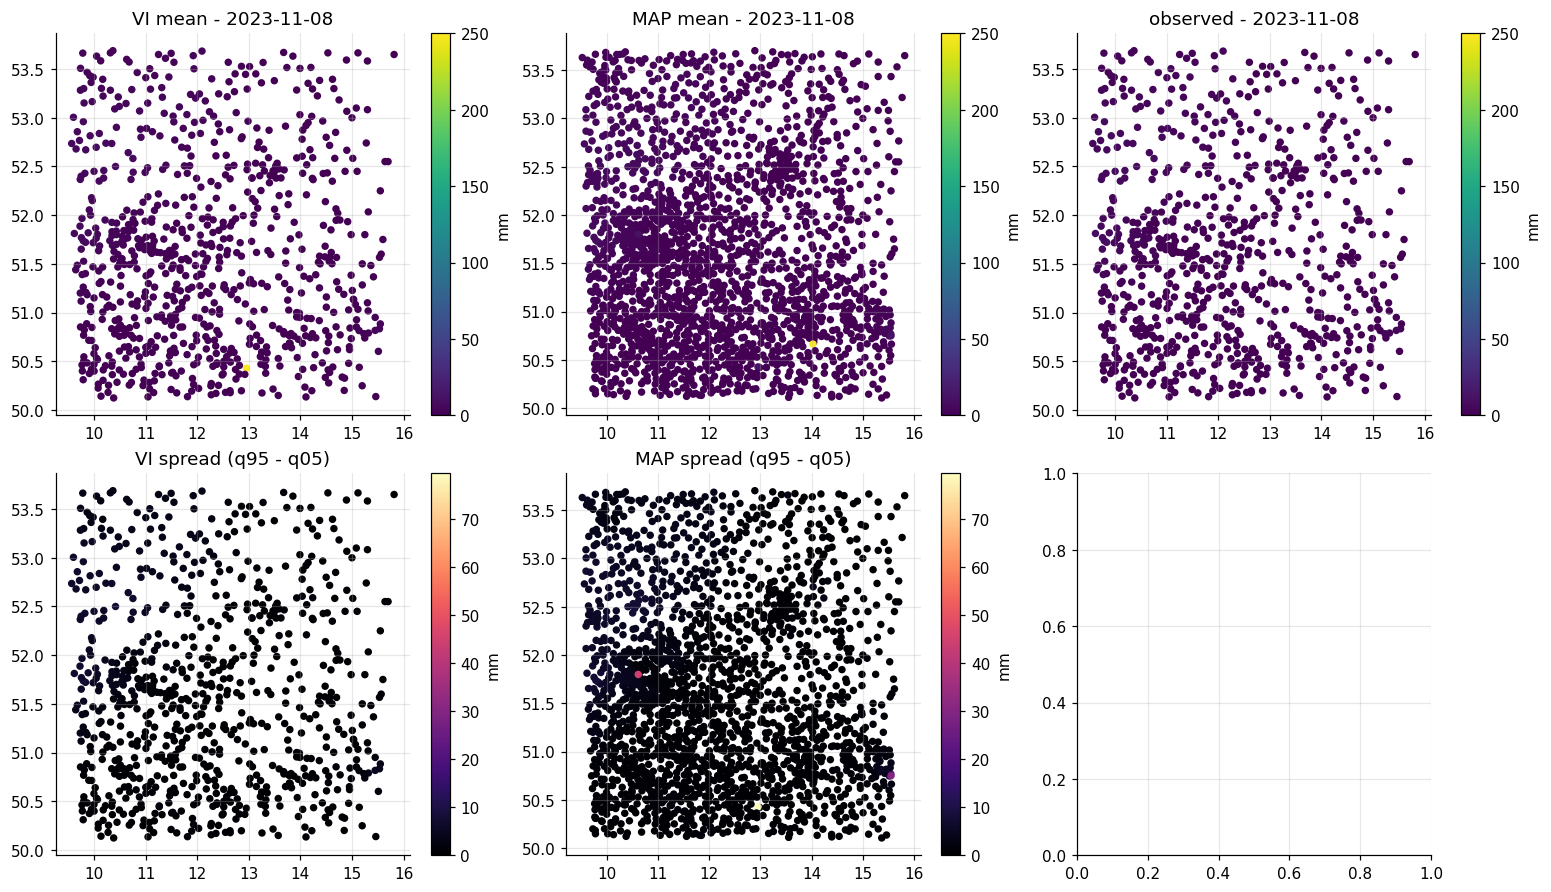

In [12]:
for day, tag in DAYS:
    vi_d  = oof_vi [oof_vi ['datetime'] == day].copy()
    map_d = oof_map[oof_map['datetime'] == day].copy()
    vi_d ['spread'] = vi_d ['q95'] - vi_d ['q05']
    map_d['spread'] = map_d['q95'] - map_d['q05']

    vmax_mean = float(np.nanmax([
        vi_d['mean_mm'].max(), map_d['mean_mm'].max(), vi_d['observed_mm'].max(),
    ]))
    vmax_spread = float(np.nanmax([vi_d['spread'].max(), map_d['spread'].max()]))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

    for ax, df, title in [(axes[0, 0], vi_d, f'VI mean - {day.date()}'),
                          (axes[0, 1], map_d, f'MAP mean - {day.date()}'),
                          (axes[0, 2], vi_d, f'observed - {day.date()}')]:
        col = 'observed_mm' if 'observed' in title else 'mean_mm'
        sc = ax.scatter(df['lon'], df['lat'], c=df[col], cmap='viridis',
                        s=15, vmin=0, vmax=vmax_mean)
        plt.colorbar(sc, ax=ax, label='mm')
        ax.set_title(title)

    for ax, df, title in [(axes[1, 0], vi_d, 'VI spread (q95 - q05)'),
                          (axes[1, 1], map_d, 'MAP spread (q95 - q05)')]:
        sc = ax.scatter(df['lon'], df['lat'], c=df['spread'], cmap='magma',
                        s=15, vmin=0, vmax=vmax_spread)
        plt.colorbar(sc, ax=ax, label='mm')
        ax.set_title(title)

    err_vi  = (vi_d ['mean_mm'] - vi_d ['observed_mm']).abs()
    err_map = (map_d['mean_mm'] - map_d['observed_mm']).abs()
    diff = err_vi.values - err_map.values
    vmax_diff = float(max(abs(diff.min()), abs(diff.max())))
    sc = axes[1, 2].scatter(vi_d['lon'], vi_d['lat'], c=diff,
                            cmap='coolwarm', s=15, vmin=-vmax_diff, vmax=vmax_diff)
    plt.colorbar(sc, ax=axes[1, 2], label='|err_VI| - |err_MAP|  (negative = VI better)')
    axes[1, 2].set_title(f'error delta - {tag}')

    fig.suptitle(f'{day.date()} ({tag})', fontsize=12)
    plt.savefig(f'thesis/text/images/05/kfold_map_{day.strftime("%Y%m%d")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


## 13. Per-station time series

Pick five stations with the largest cumulative absolute error to surface
where the two models differ most across time.


5 worst stations by cumulative |VI error|:
  DWD_1358
  CZ_P2KOSA01
  CZ_U1KLIN01
  DWD_4797
  DWD_1807


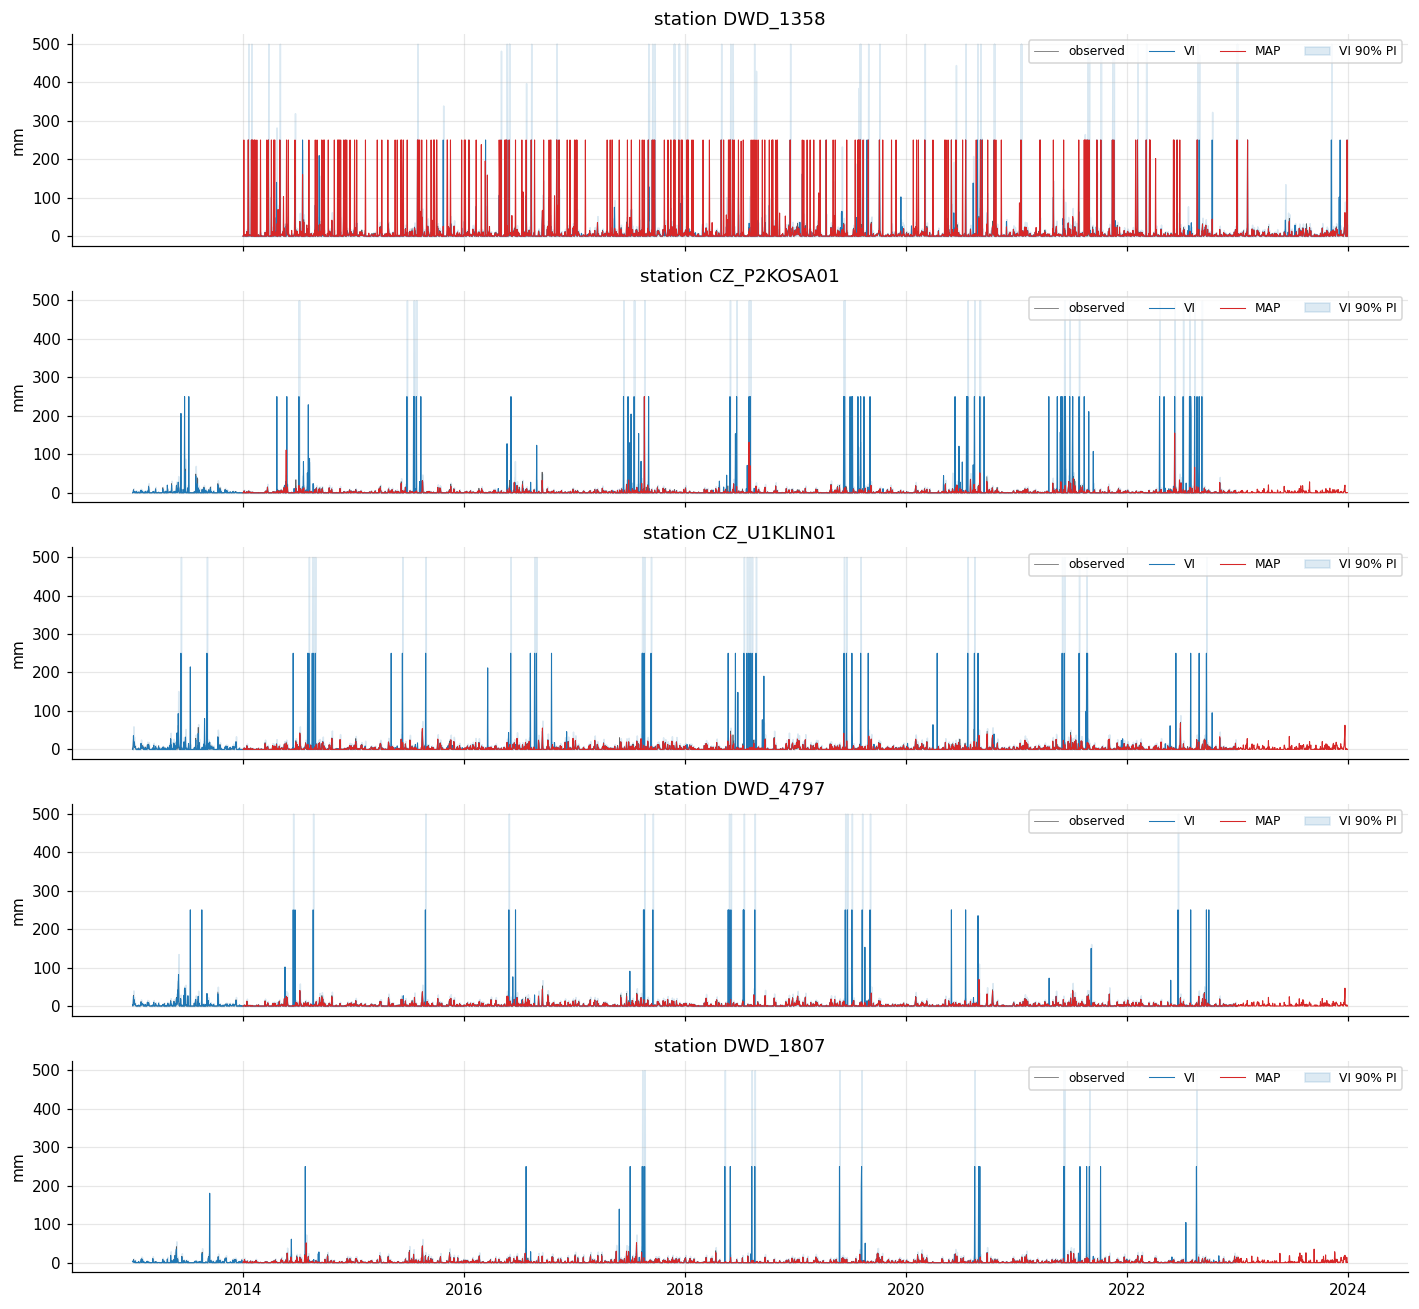

In [13]:
err = (oof_vi.set_index(['station_id', 'datetime'])['mean_mm']
       - oof_vi.set_index(['station_id', 'datetime'])['observed_mm']).abs()
worst_stations = err.groupby(level=0).sum().nlargest(5).index.tolist()
print(f'5 worst stations by cumulative |VI error|:')
for sid in worst_stations:
    print(f'  {sid}')

fig, axes = plt.subplots(len(worst_stations), 1,
                         figsize=(13, 2.4 * len(worst_stations)),
                         sharex=True)
for ax, sid in zip(axes, worst_stations):
    vi_s  = oof_vi [oof_vi ['station_id'] == sid].sort_values('datetime')
    map_s = oof_map[oof_map['station_id'] == sid].sort_values('datetime')
    ax.plot(vi_s ['datetime'], vi_s ['observed_mm'], color='black', lw=0.5,
            alpha=0.6, label='observed')
    ax.plot(vi_s ['datetime'], vi_s ['mean_mm'], color=VI_COLOR,  lw=0.7, label='VI')
    ax.plot(map_s['datetime'], map_s['mean_mm'], color=MAP_COLOR, lw=0.7, label='MAP')
    ax.fill_between(vi_s['datetime'], vi_s['q05'], vi_s['q95'],
                    color=VI_COLOR, alpha=0.15, label='VI 90% PI')
    ax.set_ylabel('mm')
    ax.set_title(f'station {sid}')
    ax.legend(fontsize=8, ncol=4, loc='upper right')

plt.tight_layout()
plt.savefig('thesis/text/images/05/kfold_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Reliability and spread-skill

Reliability: observed exceedance frequency at each forecast quantile.
A perfect probabilistic model lies on the diagonal.

Spread-skill: binned spread (q95 - q05) vs RMSE of the mean.
A well-calibrated model has matching slope.


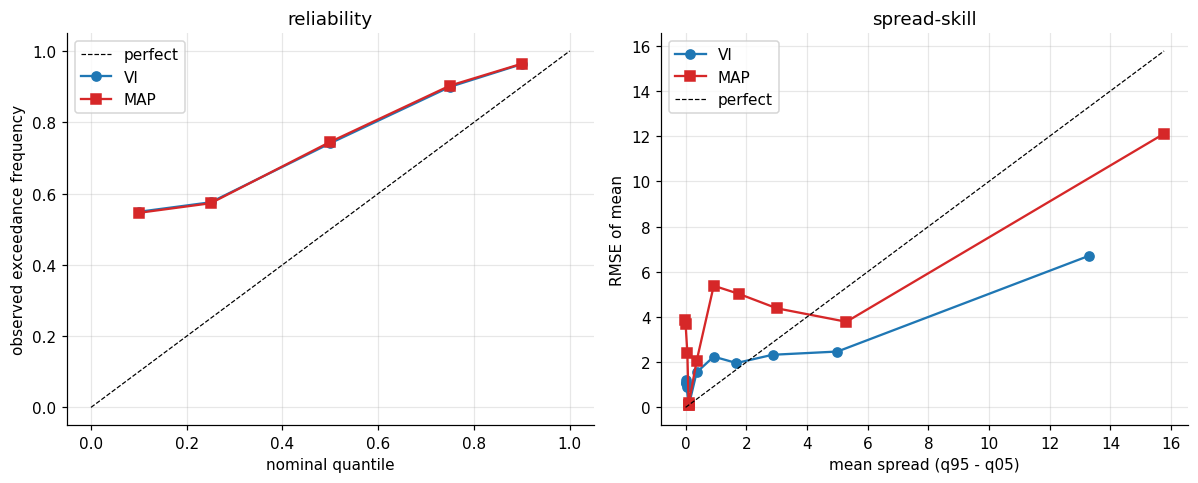

In [14]:
def _reliability(df, quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)):
    y = df['observed_mm'].to_numpy()
    qs = []
    for q in quantiles:
        # nearest column in QUANTILE_LABELS (5..95 step 5/10)
        lbl = min(QUANTILE_LABELS, key=lambda L: abs(L/100 - q))
        col = f'q{lbl:02d}'
        qs.append((q, (y <= df[col].to_numpy()).mean()))
    return pd.DataFrame(qs, columns=['nominal', 'observed'])

def _spread_skill(df, n_bins=12):
    df = df.dropna(subset=['mean_mm', 'q05', 'q95'])
    spread = (df['q95'] - df['q05']).to_numpy()
    err    = (df['mean_mm'] - df['observed_mm']).to_numpy() ** 2
    edges  = np.quantile(spread, np.linspace(0, 1, n_bins + 1))
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (spread >= lo) & (spread <= hi)
        if mask.sum() > 50:
            rows.append({'spread': spread[mask].mean(),
                         'rmse':   np.sqrt(err[mask].mean())})
    return pd.DataFrame(rows)

rel_vi  = _reliability(oof_vi )
rel_map = _reliability(oof_map)
ss_vi   = _spread_skill(oof_vi )
ss_map  = _spread_skill(oof_map)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot([0, 1], [0, 1], color='black', ls='--', lw=0.8, label='perfect')
axes[0].plot(rel_vi ['nominal'], rel_vi ['observed'], 'o-', color=VI_COLOR,  label='VI')
axes[0].plot(rel_map['nominal'], rel_map['observed'], 's-', color=MAP_COLOR, label='MAP')
axes[0].set_xlabel('nominal quantile')
axes[0].set_ylabel('observed exceedance frequency')
axes[0].set_title('reliability')
axes[0].legend()

axes[1].plot(ss_vi ['spread'], ss_vi ['rmse'], 'o-', color=VI_COLOR,  label='VI')
axes[1].plot(ss_map['spread'], ss_map['rmse'], 's-', color=MAP_COLOR, label='MAP')
mx = float(max(ss_vi['spread'].max(), ss_map['spread'].max(),
               ss_vi['rmse'].max(),   ss_map['rmse'].max()))
axes[1].plot([0, mx], [0, mx], color='black', ls='--', lw=0.8, label='perfect')
axes[1].set_xlabel('mean spread (q95 - q05)')
axes[1].set_ylabel('RMSE of mean')
axes[1].set_title('spread-skill')
axes[1].legend()

plt.tight_layout()
plt.savefig('thesis/text/images/05/kfold_reliability_spread_skill.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 15. Save aggregated metrics for the thesis text


In [15]:
out_csv = LOCAL_OOF / 'kfold_vi_vs_map_summary.csv'
df_summary.to_csv(out_csv)
print(f'saved -> {out_csv}')

print('\n=== headline numbers for thesis text ===')
for c in ['crps', 'crps_wet', 'mae', 'rmse', 'cov90', 'cov80', 'f1', 'brier']:
    vi  = df_per_fold[df_per_fold['inference'] == 'vi' ][c]
    mp  = df_per_fold[df_per_fold['inference'] == 'map'][c]
    print(f'  {c:9s}  VI = {vi.mean():.4f} +/- {vi.std():.4f}   '
          f'MAP = {mp.mean():.4f} +/- {mp.std():.4f}')


saved -> results/bayesnf/kfold_vi_vs_map_summary.csv

=== headline numbers for thesis text ===
  crps       VI = 0.2792 +/- 0.0085   MAP = 0.3105 +/- 0.0203
  crps_wet   VI = 0.6866 +/- 0.0143   MAP = 0.7230 +/- 0.0259
  mae        VI = 0.3392 +/- 0.0142   MAP = 0.4244 +/- 0.0533
  rmse       VI = 2.4345 +/- 0.5912   MAP = 4.6664 +/- 1.3645
  cov90      VI = 0.9574 +/- 0.0030   MAP = 0.9595 +/- 0.0031
  cov80      VI = 0.9325 +/- 0.0040   MAP = 0.9338 +/- 0.0039
  f1         VI = 0.9448 +/- 0.0014   MAP = 0.9452 +/- 0.0020
  brier      VI = 0.0416 +/- 0.0011   MAP = 0.0417 +/- 0.0015
